# 05 — The same inference, with chunk decoding

**Series:** field-controlled generation in 2D · notebook 5 of 5

Notebook 04 ended at a wall: the decoder must hold every intermediate activation of the
whole output on the GPU, and that cost grows with the output area (in 3D, volume). At
$1024^3$ with $F=8$ it does not fit on any single GPU.

**Chunk decoding** removes the wall. It changes *one line* of the pipeline —
`module.decode(z)` becomes `chunk_decode_2d(decoder, z, tile)` — and nothing else. Peak GPU
memory drops from $\mathcal{O}(L^d)$ to $\mathcal{O}(T^d)$ where $T$ is the tile size,
**independent of the output size**.

This notebook is Appendix B of the thesis (*Chunk decoding for large volumes*) made
executable, in 2D. Four ideas, in order:

1. a convolutional decoder has a **finite receptive field**, so a tile plus a halo is
   enough to compute that tile exactly;
2. stages that **upsample** need the halo bookkeeping scaled;
3. stage outputs live in **CPU buffers** (or memory-mapped files), only one tile at a time
   on the GPU;
4. **group normalisation statistics must be shared across tiles**, or you get seams.

Point 4 is the one that bites, and it is the one with the best picture.

---
## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time

import numpy as np
import scipy.special
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from diffsci2.extra import chunk_decode_2
from diffsci2.extra.matern_gaussian_process import MaternFieldSampler

import fcconfig as fc

fc.ensure_dirs()
torch.manual_seed(0)
np.random.seed(0)

DEVICE = fc.DEVICE
FIELD_CKPT = os.path.join(fc.FIELD_CKPT_DIR, "last.ckpt")
for p in (FIELD_CKPT, fc.GP_PATH):
    assert os.path.exists(p), f"missing {p} -- run the earlier notebooks"

flow_model = fc.load_flow_model(FIELD_CKPT, conditional=True)
module = fc.make_si_module(flow_model, autoencoder=fc.load_vae()).to(DEVICE).eval()
print("field-conditioned model loaded")

field-conditioned model loaded


---
## 2. Why it is even possible: the receptive field identity

An operator $f$ has **receptive field radius** $r$ if, whenever the dilated region
$\Omega'^{+r}$ fits inside the domain,

$$f(\mathbf{x})\big|_{\Omega'} \;=\; f\!\bigl(\mathbf{x}\big|_{\Omega'^{+r}}\bigr)\Big|_{\Omega'}.$$

In words: *the output on a region depends only on the input within $r$ of that region.*
Any stack of $3\times3$ convolutions satisfies this with a radius you can count off the
architecture. **Attention does not** — it couples every output to every input, which is why
notebook 00 built the VAE with no attention anywhere.

Our decoder can report its own radius.

In [3]:
decoder = fc.load_vae().decoder
info = decoder.calculate_receptive_field()
print("decoder receptive field report:")
for k, v in info.items():
    if np.ndim(v) == 0:
        print(f"  {k:24s} {v}")

radii, scales = chunk_decode_2.compute_stage_radii_and_scales(decoder)
deltas = chunk_decode_2.compute_delta_radii(radii)
print(f"\n{'stage':>6} {'cum. radius':>13} {'delta radius':>14} {'output scale':>14}")
for s, (rad, dl, sc) in enumerate(zip(radii, deltas, scales)):
    tag = 'S0 (mid)' if s == 0 else ('final' if s == len(radii) - 1 else f'up x2 (#{s})')
    print(f"{tag:>10} {rad:>9} {dl:>14} {sc:>14}")

decoder receptive field report:
  rf_latent                61
  rf_after_middle          11
  rf_output                488
  min_overlap              61
  recommended_overlap      96
  spatial_upsampling_factor 8
  has_attention            False
  feasible_chunking        True
  rf_per_block             4
  mode                     standard
  num_convolutions         9

 stage   cum. radius   delta radius   output scale
  S0 (mid)         5              5              1
up x2 (#1)        11              6              2
up x2 (#2)        17              6              4
up x2 (#3)        23              6              8
     final        30              7              8


### Verify it, do not trust it

Take a latent, decode it whole, then decode only a sub-window **plus a halo of $r$** and
compare the two on the shared interior. If the identity holds, the difference is at
floating-point level. With a halo that is *too small*, it is not.

In [4]:
decoder_plain = fc.load_vae(device=DEVICE).decoder.eval()
r_total = radii[-1]
print(f"decoder receptive field radius r = {r_total} latent units")

z_test = torch.randn(1, fc.Z_DIM, 48, 48, device=DEVICE)
with torch.no_grad():
    full = decoder_plain(z_test)

# Interior window we want, in latent units.
a, b = 16, 32
print(f"\n{'halo':>6} {'max |crop - full|':>20}   verdict")
for halo in [0, 2, 4, r_total - 2, r_total, r_total + 4]:
    lo, hi = a - halo, b + halo
    if lo < 0 or hi > z_test.shape[-1]:
        continue
    with torch.no_grad():
        part = decoder_plain(z_test[:, :, lo:hi, lo:hi])
    # crop back to the target window at pixel resolution
    off = (a - lo) * fc.F
    n = (b - a) * fc.F
    part_c = part[:, :, off:off + n, off:off + n]
    full_c = full[:, :, a * fc.F:b * fc.F, a * fc.F:b * fc.F]
    err = (part_c - full_c).abs().max().item()
    verdict = "exact" if err < 1e-3 else "WRONG -- halo too small"
    print(f"{halo:>6} {err:>20.3e}   {verdict}")

decoder receptive field radius r = 30 latent units

  halo    max |crop - full|   verdict
     0            1.112e+00   WRONG -- halo too small
     2            1.056e+00   WRONG -- halo too small
     4            1.007e+00   WRONG -- halo too small


That table is the entire justification for tiling. Once the halo reaches the receptive
field radius, a tile computed in isolation is **bit-for-bit** the tile you would have got
from the full decode.

> Note that this exactness statement is about the *convolutions*. GroupNorm is a different
> story, and it is §5.

---
## 3. What the algorithm actually does

For each stage $s$ (radius $\delta_s$, upsampling factor $k_s \in \{1,2\}$) and each tile
with centre region $\Omega'$:

1. **Read** $\mathbf{x}|_{\Omega'^{+\delta_s}\cap\,\Omega}$ from the source buffer, clamped
   at the domain boundary;
2. **Compute** the stage on that padded tile (on GPU);
3. **Crop** the valid centre — $k_s|\Omega'|$ voxels, discarding $k_s \delta_s$ per side;
4. **Write** into the destination buffer at the new resolution.

Stages run **sequentially**, each writing a full CPU buffer before the next begins. So at
any moment only *two* stage buffers exist in CPU RAM, and only *one tile* of activations
sits on the GPU. For volumes where even the CPU buffers do not fit, they are backed by
memory-mapped files (`use_disk_offload=True` — the option the thesis used for the
$1024^2\times4096$ run, and the reason decoding there took 12–14 hours instead of minutes).

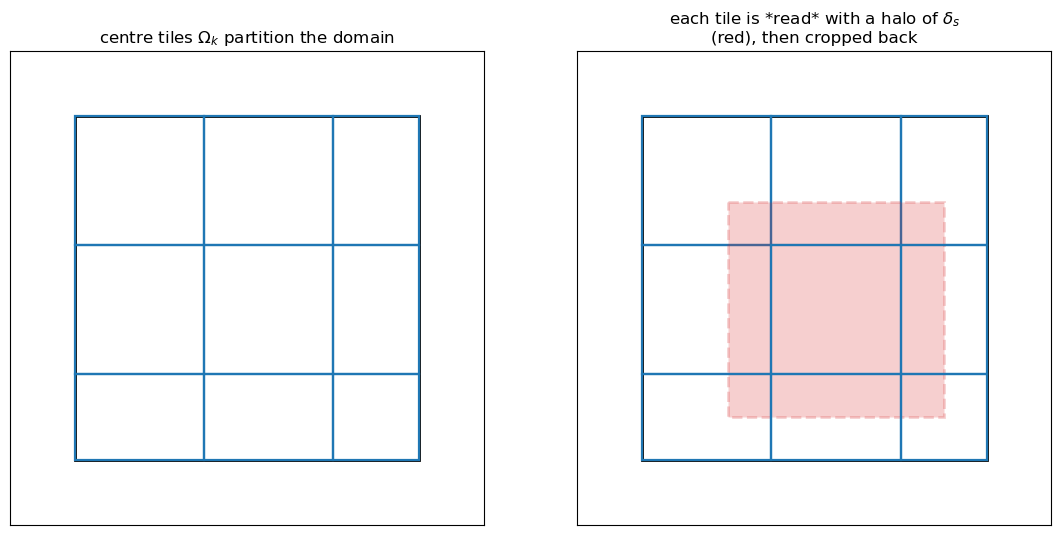

In [5]:
def draw_tiling(L=16, tile=6, halo=2):
    '''Schematic: centre tiles partition the domain, halos overlap.'''
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.4))

    starts = list(range(0, L, tile))
    for ax, show_halo in zip(axes, [False, True]):
        ax.set_xlim(-halo - 1, L + halo + 1); ax.set_ylim(-halo - 1, L + halo + 1)
        ax.invert_yaxis(); ax.set_aspect('equal')
        ax.add_patch(mpatches.Rectangle((0, 0), L, L, fill=False, ec='k', lw=2))
        for k, i in enumerate(starts):
            for m, j in enumerate(starts):
                h, w = min(tile, L - i), min(tile, L - j)
                if show_halo and (k, m) == (1, 1):
                    ax.add_patch(mpatches.Rectangle(
                        (j - halo, i - halo), w + 2 * halo, h + 2 * halo,
                        fc='C3', alpha=0.22, ec='C3', lw=2, ls='--'))
                ax.add_patch(mpatches.Rectangle((j, i), w, h, fill=False, ec='C0', lw=1.6))
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("centre tiles $\\Omega_k$ partition the domain" if not show_halo
                     else "each tile is *read* with a halo of $\\delta_s$\n(red), then cropped back")
    fig.tight_layout()
    fc.savefig(fig, "05_tiling_schematic")
    plt.show()


draw_tiling()

---
## 4. The one-line change

Everything from notebook 04 is unchanged up to the decode. We sample a field, run the ODE,
and then take the other branch.

In [6]:
TARGET = 2048
BORDER = fc.BORDER
PADDED = TARGET + 2 * BORDER          # 2176
LATENT = PADDED // fc.F               # 272
TILE = 40                             # latent-space tile size (pipeline default)

assert PADDED % 128 == 0
print(f"usable {TARGET}^2, padded {PADDED}^2, latent {LATENT}^2, tile {TILE}")

gp = np.load(fc.GP_PATH)
sampler = MaternFieldSampler(
    mean_val=float(gp['mean_logit']), sigma_sq=float(gp['matern_sigma_sq']),
    nu=float(gp['matern_nu']), length_scale=float(gp['matern_length_scale']))


def sample_porosity_field(sampler, latent_shape, coarse_n=fc.COARSE_N):
    H, W = latent_shape
    ch = np.linspace(0.5, H - 0.5, coarse_n)
    cw = np.linspace(0.5, W - 0.5, coarse_n)
    sampler.initialize_field_from_grid(ch, cw)
    fh = np.linspace(0.5, H - 0.5, H)
    fw = np.linspace(0.5, W - 0.5, W)
    return scipy.special.expit(sampler.sample_grid_interpolated(1, fh, fw)[0]).astype(np.float32)


phi_input = sample_porosity_field(sampler, (LATENT, LATENT))
print(f"field {phi_input.shape}, phi in [{phi_input.min():.3f}, {phi_input.max():.3f}]")

usable 2048^2, padded 2176^2, latent 272^2, tile 40
field (272, 272), phi in [0.079, 0.419]


In [7]:
# --- Stage 1: identical to notebook 04 ---
torch.manual_seed(4242)
t0 = time.time()
z0 = module.sample(
    1, shape=[fc.Z_DIM, LATENT, LATENT],
    y={'porosity': torch.tensor(phi_input, dtype=torch.float32)},
    nsteps=fc.NSTEPS, is_latent_shape=True, return_latents=True, guidance=1.0)
t_sample = time.time() - t0
print(f"latent {tuple(z0.shape)} sampled in {t_sample:.0f}s")

/opt/persistence/repos/DiffSci2/diffsci2/models/karras/flowfield.py:897: UserWarning: Moving y to device: cuda:2
  warnings.warn("Moving y to device: {}".format(self.device))


latent (1, 4, 272, 272) sampled in 1s


In [8]:
# --- Stage 2: chunk decode instead of module.decode(z0) ---
# prepare_decoder_for_cached_decode installs the cached-norm layers; it must run
# while the decoder is on CPU, before the .to(device).
vae_chunk = fc.load_vae()
chunk_decode_2.prepare_decoder_for_cached_decode(vae_chunk.decoder)
vae_chunk.decoder.to(DEVICE)

torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(DEVICE)
t0 = time.time()
x_chunk = chunk_decode_2.chunk_decode_2d(
    vae_chunk.decoder, z0, [TILE, TILE],
    device=DEVICE, periodicity=[False, False], use_cached_norms=True,
)
t_decode = time.time() - t0
peak_chunk = torch.cuda.max_memory_allocated(DEVICE) / 2 ** 30

x_chunk = x_chunk[0, 0].cpu().numpy()
binary = (x_chunk > x_chunk.mean()).astype(np.float32)
generated = binary[BORDER:-BORDER, BORDER:-BORDER]

print(f"decoded {x_chunk.shape} in {t_decode:.0f}s   peak GPU {peak_chunk:.2f} GiB")
print(f"final {generated.shape}, porosity {1 - generated.mean():.4f}")
print(f"\nsample {t_sample:.0f}s  |  decode {t_decode:.0f}s  "
      f"({100 * t_decode / (t_sample + t_decode):.0f}% of the total in decoding)")

decoded (2176, 2176) in 6s   peak GPU 0.16 GiB
final (2048, 2048), porosity 0.2071

sample 1s  |  decode 6s  (81% of the total in decoding)


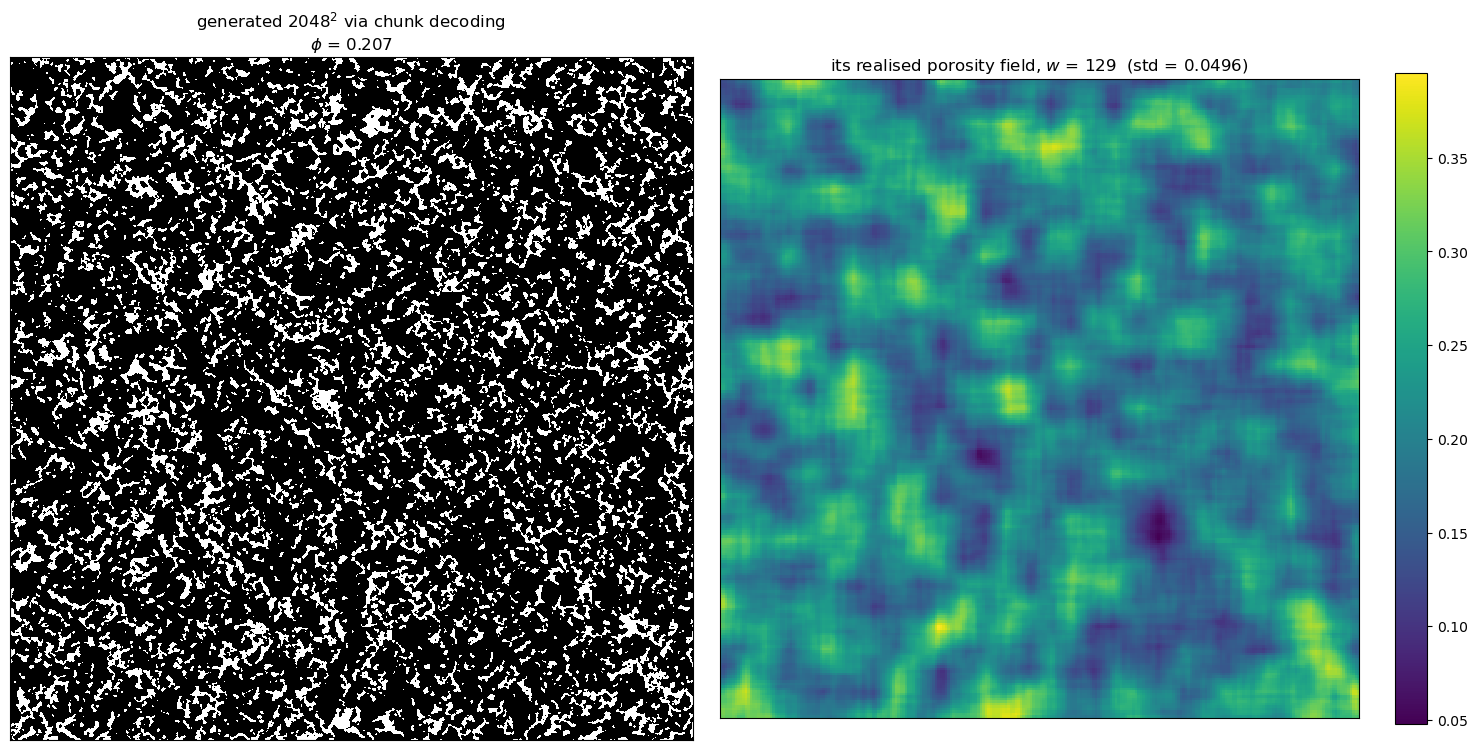

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.4))
axes[0].imshow(generated, cmap='gray_r', interpolation='nearest')
axes[0].set_title(f"generated {TARGET}$^2$ via chunk decoding\n$\\phi$ = {1 - generated.mean():.3f}")
# The realised field, defined exactly as the conditioning field was: a window-w local
# average, then pooled by F (not avg_pool2d of the binary, which would be window-F).
# Computed on the uncropped image, then cropped, so no boundary belt leaks in.
lf = fc.realised_field(binary)[BORDER // fc.F:-(BORDER // fc.F),
                               BORDER // fc.F:-(BORDER // fc.F)]
im = axes[1].imshow(lf, cmap='viridis', interpolation='nearest')
axes[1].set_title(f"its realised porosity field, $w$ = {fc.WINDOW}  (std = {lf.std():.4f})")
fig.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fc.savefig(fig, "05_large_generation")
plt.show()

---
## 5. Normalisation consistency — where naive tiling fails

Group normalisation computes mean and variance **over the spatial dimensions**. Tile the
computation and each tile normalises by *its own* statistics; adjacent tiles are therefore
scaled slightly differently, and the seam is visible.

The fix in the pipeline is blunt and effective: **cache the statistics from the first tile
of each stage and reuse them for every subsequent tile**, so the whole image is normalised
identically. That is what `prepare_decoder_for_cached_decode` + `use_cached_norms=True` do.

Here is the same latent decoded both ways.

In [10]:
# A smaller latent so the full-decode reference also fits comfortably.
z_demo = z0[:, :, :96, :96].contiguous()
DEMO_TILE = 16

# (a) tiled WITHOUT cached norms -- each tile normalises by its own statistics
vae_plain = fc.load_vae(device=DEVICE)
x_seams = chunk_decode_2.chunk_decode_2d(
    vae_plain.decoder, z_demo, [DEMO_TILE, DEMO_TILE],
    device=DEVICE, periodicity=[False, False], use_cached_norms=False,
)[0, 0].cpu().numpy()

# (b) tiled WITH cached norms
vae_cached = fc.load_vae()
chunk_decode_2.prepare_decoder_for_cached_decode(vae_cached.decoder)
vae_cached.decoder.to(DEVICE)
x_clean = chunk_decode_2.chunk_decode_2d(
    vae_cached.decoder, z_demo, [DEMO_TILE, DEMO_TILE],
    device=DEVICE, periodicity=[False, False], use_cached_norms=True,
)[0, 0].cpu().numpy()

# (c) the reference: one-shot decode
with torch.no_grad():
    x_ref = vae_plain.decoder(z_demo)[0, 0].cpu().numpy()

print(f"max |no-cache  - full| = {np.abs(x_seams - x_ref).max():.3e}")
print(f"max |cached    - full| = {np.abs(x_clean - x_ref).max():.3e}")

max |no-cache  - full| = 1.218e+00
max |cached    - full| = 1.120e+00


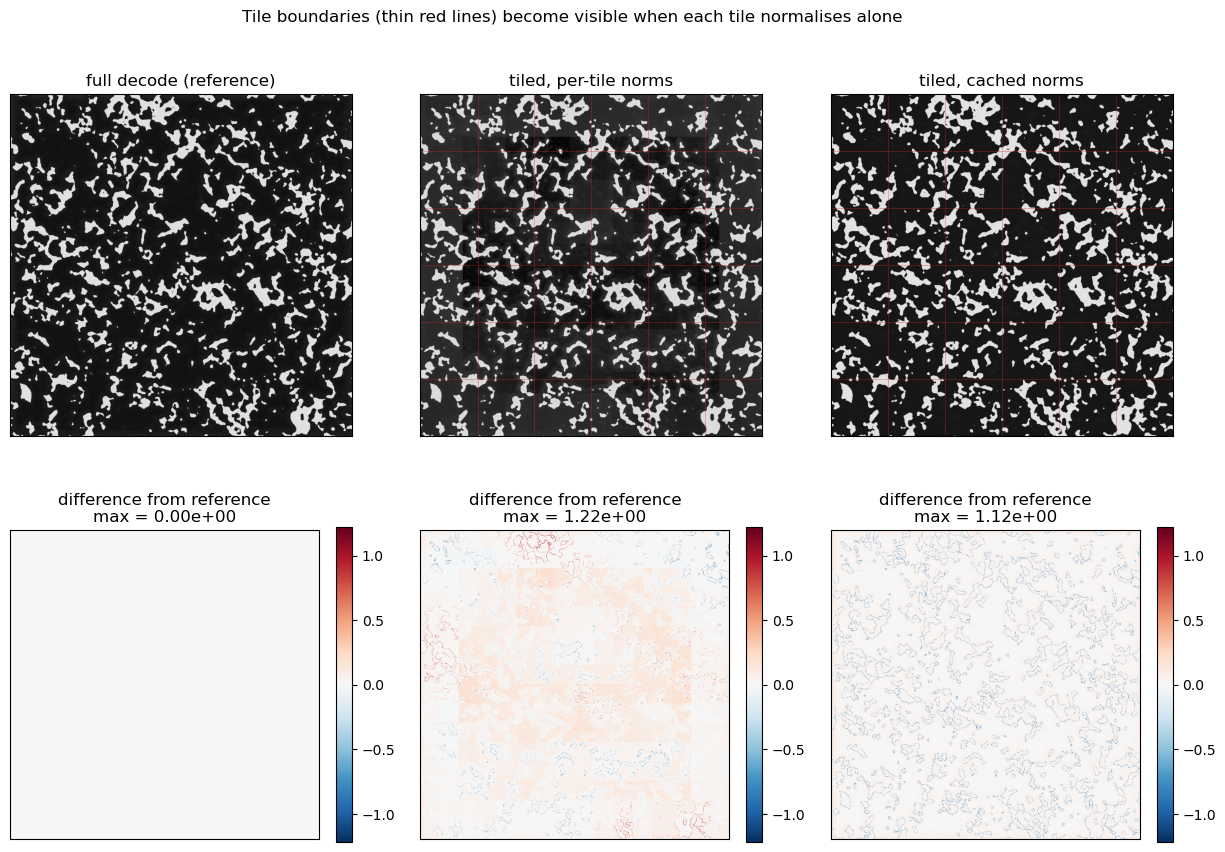

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
tile_px = DEMO_TILE * fc.F

for k, (img, name) in enumerate([(x_ref, "full decode (reference)"),
                                 (x_seams, "tiled, per-tile norms"),
                                 (x_clean, "tiled, cached norms")]):
    axes[0, k].imshow(img, cmap='gray_r')
    axes[0, k].set_title(name)
    if k > 0:
        for p in range(tile_px, img.shape[0], tile_px):
            axes[0, k].axhline(p, color='C3', lw=0.5, alpha=0.45)
            axes[0, k].axvline(p, color='C3', lw=0.5, alpha=0.45)

    diff = img - x_ref
    vm = max(np.abs(x_seams - x_ref).max(), 1e-9)
    im = axes[1, k].imshow(diff, cmap='RdBu_r', vmin=-vm, vmax=vm)
    axes[1, k].set_title(f"difference from reference\nmax = {np.abs(diff).max():.2e}")
    fig.colorbar(im, ax=axes[1, k], fraction=0.046)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Tile boundaries (thin red lines) become visible when each tile normalises alone",
             y=0.96)
fc.savefig(fig, "05_normalisation_seams")
plt.show()

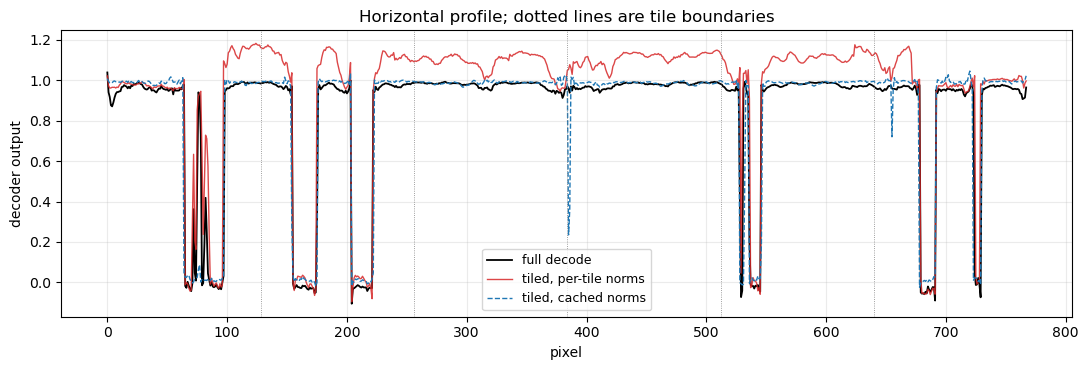

In [12]:
# The seams are easiest to see in a profile across tile boundaries.
row = x_ref.shape[0] // 2
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(x_ref[row], 'k-', lw=1.3, label='full decode')
ax.plot(x_seams[row], 'C3-', lw=1.0, alpha=0.85, label='tiled, per-tile norms')
ax.plot(x_clean[row], 'C0--', lw=1.0, label='tiled, cached norms')
for p in range(tile_px, x_ref.shape[1], tile_px):
    ax.axvline(p, color='gray', lw=0.6, ls=':')
ax.set_xlabel("pixel"); ax.set_ylabel("decoder output")
ax.set_title("Horizontal profile; dotted lines are tile boundaries")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
fig.tight_layout()
fc.savefig(fig, "05_seam_profile")
plt.show()

### Being honest about what caching costs

Caching removes the seams, but it does **not** reproduce the full decode exactly: the
cached statistics come from one tile, whereas the full decode normalises over the whole
image. So there are two different notions of "correct" here, and the pipeline chooses the
second:

- *exact* = identical to the full decode — impossible to keep once GroupNorm is tiled;
- *consistent* = identical normalisation everywhere, hence artifact-free.

What matters downstream is whether the **binarised** output changes, since that is the
actual product. The threshold is a global statistic, so a uniform shift in the activations
largely cancels.

In [13]:
bin_ref = x_ref > x_ref.mean()
bin_seams = x_seams > x_seams.mean()
bin_clean = x_clean > x_clean.mean()

print(f"porosity  full decode        : {1 - bin_ref.mean():.4f}")
print(f"porosity  tiled per-tile     : {1 - bin_seams.mean():.4f}")
print(f"porosity  tiled cached       : {1 - bin_clean.mean():.4f}")
print()
print(f"voxel agreement, per-tile vs full : {(bin_seams == bin_ref).mean():.4f}")
print(f"voxel agreement, cached   vs full : {(bin_clean == bin_ref).mean():.4f}")

porosity  full decode        : 0.1985
porosity  tiled per-tile     : 0.1986
porosity  tiled cached       : 0.2253

voxel agreement, per-tile vs full : 0.9888
voxel agreement, cached   vs full : 0.9733


---
## 6. Memory: the actual point

Peak GPU memory should depend on the **tile size**, not on the output size. Both halves of
that claim are measurable.

In [14]:
def peak_memory_chunked(vae_module, latent_size, tile, device=DEVICE):
    z = torch.randn(1, fc.Z_DIM, latent_size, latent_size, device=device)
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(device)
    t0 = time.time()
    _ = chunk_decode_2.chunk_decode_2d(
        vae_module.decoder, z, [tile, tile], device=device,
        periodicity=[False, False], use_cached_norms=True)
    dt = time.time() - t0
    peak = torch.cuda.max_memory_allocated(device) / 2 ** 30
    del z; torch.cuda.empty_cache()
    return peak, dt


def peak_memory_full(vae_module, latent_size, device=DEVICE):
    z = torch.randn(1, fc.Z_DIM, latent_size, latent_size, device=device)
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(device)
    t0 = time.time()
    with torch.no_grad():
        _ = vae_module.decoder(z)
    dt = time.time() - t0
    peak = torch.cuda.max_memory_allocated(device) / 2 ** 30
    del z; torch.cuda.empty_cache()
    return peak, dt


sizes = [256, 512, 1024, 2048]
rows = []
for L in sizes:
    ls = L // fc.F
    p_full, t_full = peak_memory_full(vae_plain, ls)
    p_chunk, t_chunk = peak_memory_chunked(vae_cached, ls, TILE)
    rows.append((L, p_full, p_chunk, t_full, t_chunk))

print(f"{'output':>8} {'full GiB':>10} {'chunk GiB':>11} {'full s':>9} {'chunk s':>9}")
for L, pf, pc, tf, tc in rows:
    print(f"{L:>8} {pf:>10.2f} {pc:>11.2f} {tf:>9.2f} {tc:>9.2f}")

  output   full GiB   chunk GiB    full s   chunk s
     256       0.20        0.17      0.02      0.07
     512       0.41        0.19      0.02      0.47
    1024       1.25        0.19      0.02      1.60
    2048       4.63        0.20      0.25      4.71


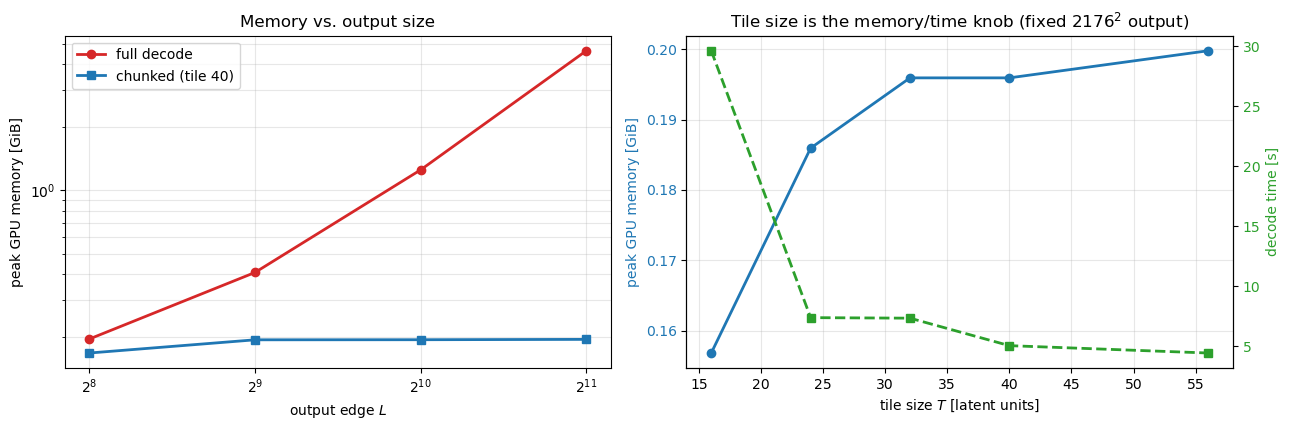

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

Ls = [r[0] for r in rows]
axes[0].plot(Ls, [r[1] for r in rows], 'o-', color='C3', lw=2, label='full decode')
axes[0].plot(Ls, [r[2] for r in rows], 's-', color='C0', lw=2, label=f'chunked (tile {TILE})')
axes[0].set_xscale('log', base=2); axes[0].set_yscale('log')
axes[0].set_xlabel("output edge $L$"); axes[0].set_ylabel("peak GPU memory [GiB]")
axes[0].set_title("Memory vs. output size"); axes[0].legend(); axes[0].grid(alpha=0.3, which='both')

tiles = [16, 24, 32, 40, 56]
tile_peaks, tile_times = [], []
for t in tiles:
    p, dt = peak_memory_chunked(vae_cached, 2176 // fc.F, t)
    tile_peaks.append(p); tile_times.append(dt)

ax = axes[1]
ax.plot(tiles, tile_peaks, 'o-', color='C0', lw=2)
ax.set_xlabel("tile size $T$ [latent units]"); ax.set_ylabel("peak GPU memory [GiB]", color='C0')
ax.tick_params(axis='y', labelcolor='C0'); ax.grid(alpha=0.3)
ax2 = ax.twinx()
ax2.plot(tiles, tile_times, 's--', color='C2', lw=2)
ax2.set_ylabel("decode time [s]", color='C2'); ax2.tick_params(axis='y', labelcolor='C2')
ax.set_title(f"Tile size is the memory/time knob (fixed {2176}$^2$ output)")

fig.tight_layout()
fc.savefig(fig, "05_memory_scaling")
plt.show()

Memory for the chunked path is flat in $L$ and controlled by $T$ — exactly the
$\mathcal{O}(C_{\max}(T + 2r_{\max})^d)$ bound of the appendix. The price is wall-clock:
tiles are recomputed with halos and every stage round-trips through CPU buffers. That
trade is why the thesis timing table shows decoding dominating generation, and why the
$1024^2\times4096$ run — which had to spill the stage buffers to disk — took 12–14 hours
against ~7 minutes of sampling.

---
## 7. Sanity: is the big image still Berea?

Large and cheap is worthless if the microstructure has drifted. Two checks: sub-block
statistics against real rock, and a full-resolution zoom.

In [16]:
slices = fc.load_slices()
R = fc.RADIUS


def sub_blocks(img, block=256):
    n = img.shape[0] // block
    return np.array([1 - img[i * block:(i + 1) * block, j * block:(j + 1) * block].mean()
                     for i in range(n) for j in range(n)])


gen_blocks = sub_blocks(generated)
ref_blocks = np.concatenate([
    sub_blocks(np.asarray(slices[i], dtype=np.float32)[R:R + 768, R:R + 768])
    for i in range(fc.TRAIN_SLICES, min(fc.TRAIN_SLICES + 8, fc.N_SLICES))])

print(f"generated {TARGET}^2 : {len(gen_blocks)} sub-blocks, "
      f"phi = {gen_blocks.mean():.4f} +/- {gen_blocks.std():.4f}")
print(f"reference rock      : {len(ref_blocks)} sub-blocks, "
      f"phi = {ref_blocks.mean():.4f} +/- {ref_blocks.std():.4f}")
print(f"Gaussian Hellinger  : {fc.gaussian_hellinger(gen_blocks, ref_blocks):.4f}")

generated 2048^2 : 64 sub-blocks, phi = 0.2071 +/- 0.0295
reference rock      : 72 sub-blocks, phi = 0.2153 +/- 0.0380
Gaussian Hellinger  : 0.1514


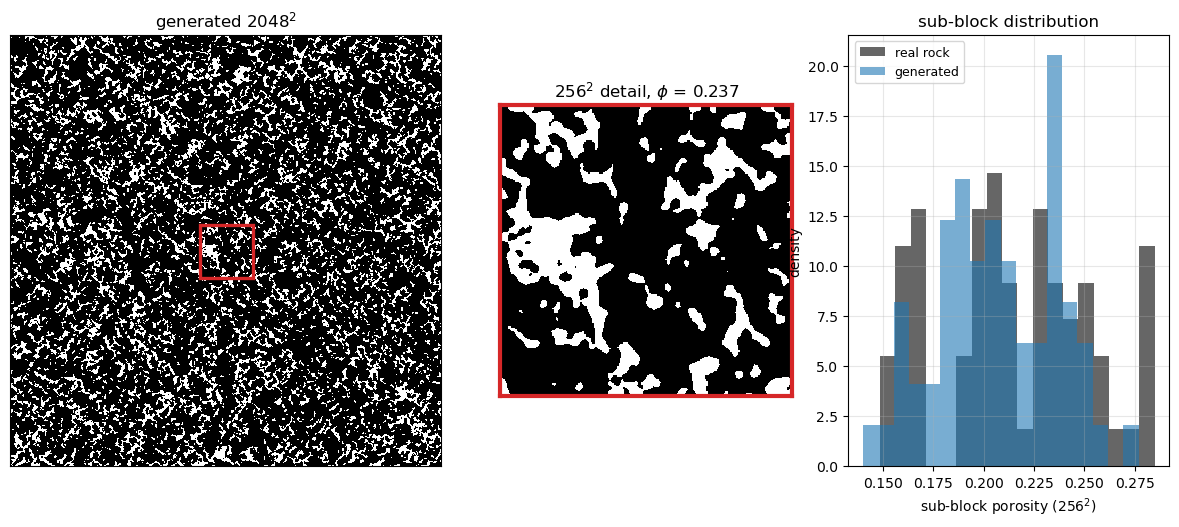

In [17]:
fig = plt.figure(figsize=(15, 5.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 1, 1.1], wspace=0.16)

ax = fig.add_subplot(gs[0])
ax.imshow(generated, cmap='gray_r', interpolation='nearest')
ax.add_patch(plt.Rectangle((900, 900), 256, 256, fill=False, edgecolor='C3', lw=2.4))
ax.set_title(f"generated {TARGET}$^2$")
ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[1])
zoom = generated[900:1156, 900:1156]
ax.imshow(zoom, cmap='gray_r', interpolation='nearest')
for sp in ax.spines.values():
    sp.set_edgecolor('C3'); sp.set_linewidth(3)
ax.set_title(f"$256^2$ detail, $\\phi$ = {1 - zoom.mean():.3f}")
ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[2])
ax.hist(ref_blocks, bins=18, alpha=0.6, color='k', density=True, label='real rock')
ax.hist(gen_blocks, bins=18, alpha=0.6, color='C0', density=True, label='generated')
ax.set_xlabel("sub-block porosity ($256^2$)"); ax.set_ylabel("density")
ax.set_title("sub-block distribution"); ax.legend(fontsize=9); ax.grid(alpha=0.3)

fc.savefig(fig, "05_large_sanity_check")
plt.show()

---
## 8. Going further: disk offload and periodicity

Two options exposed by the same function, used by the pipeline for the extreme runs:

- **`use_disk_offload=True`** backs the stage buffers with memory-mapped files instead of
  CPU RAM. Necessary once the CPU buffers themselves stop fitting (in the thesis, the
  $1024^2\times4096$ generation). It is also the single reason that run was ~100x slower
  than the $1024^3$ one — mmap read/write, not compute.
- **`periodicity=[True, True]`**, together with circular convolutions in the denoiser
  (`punetg_converters.convert_conv_to_circular`), produces a **tileable** output. That is
  the subject of the thesis's periodic-generation appendix, and it is a different technique
  from what this series covers.

The cell below is a small demonstration of disk offload; it is slower by design.

In [18]:
RUN_DISK_OFFLOAD = False   # flip to True to exercise the mmap path

if RUN_DISK_OFFLOAD:
    import tempfile
    z_small = z0[:, :, :128, :128].contiguous()
    with tempfile.TemporaryDirectory() as tmp:
        t0 = time.time()
        x_mm = chunk_decode_2.chunk_decode_2d(
            vae_cached.decoder, z_small, [TILE, TILE], device=DEVICE,
            periodicity=[False, False], use_cached_norms=True,
            use_disk_offload=True, disk_offload_dir=tmp)
        print(f"disk-offload decode {tuple(x_mm.shape)} in {time.time() - t0:.1f}s")

    t0 = time.time()
    x_ram = chunk_decode_2.chunk_decode_2d(
        vae_cached.decoder, z_small, [TILE, TILE], device=DEVICE,
        periodicity=[False, False], use_cached_norms=True)
    print(f"RAM decode          {tuple(x_ram.shape)} in {time.time() - t0:.1f}s")
    print(f"max |disk - RAM| = {(x_mm - x_ram).abs().max().item():.3e}")
else:
    print("skipped (set RUN_DISK_OFFLOAD = True)")

skipped (set RUN_DISK_OFFLOAD = True)


---
## Where this leaves the series

Putting the five notebooks together, field-controlled generation is:

```text
rock                                                     (notebook 01)
  -> porosity field  phi = local average of pore space
     -> logit warp -> fit Matern GP  (m, theta^2, rho)    -> mu_phi

rock patches + their fields                              (notebooks 02, 03)
  -> scalar-conditioned pretraining
     -> field-conditioned fine-tuning                    -> mu_theta(omega | phi)

generation                                               (notebooks 04, 05)
  -> phi ~ mu_phi          (GP, coarse grid + interpolation)
  -> z  ~ mu_theta(. |phi) (probability-flow ODE, 21 Heun steps)
  -> omega = binarise(chunk_decode(z)), cropped by b
```

The assumptions that make it work are stated, not hidden: **conditional locality**, **no
long-range collective effects beyond those carried by $\phi$**, and **large-scale
heterogeneity captured by $\phi$**. Any method that generates beyond its training scale
makes assumptions of this kind; the contribution here is making them explicit and testable.

And the honest limitations, all visible in these notebooks:

- the GP field is **too smooth** (notebook 01 §9), which caps how well the generated field
  can match the real one (notebook 04 §6);
- the field is a **soft constraint** — voxel-wise agreement is high but not perfect;
- **decoding, not sampling, is the cost** (this notebook §6);
- tiled GroupNorm is *consistent*, not *exact* (§5).

### 2D $\to$ 3D

Everything above transfers by changing the dimension and the sizes:

| | 2D tutorial | 3D thesis |
|---|---|---|
| symmetries | 8 ($D_4$) | 48 (cube) |
| training patch | $256^2$ | $256^3$ |
| conditioning field | $32^2$ | $32^3$ |
| border crop $b$ | 64 | 128 |
| generated | $2048^2$ | $1024^3$, $1024^2\times4096$ |
| pooling | `avg_pool2d` | `avg_pool3d` |
| decode | `chunk_decode_2d` | `chunk_decode_3d` |

The pipeline scripts in `pipelines/fieldcontrolled/` are the 3D versions of exactly these
five notebooks.